# Análisis de Resultados: Método de Newton para $(z-1)^m(z+1)$

Este notebook analiza cómo varían el punto de transición en el eje real y el porcentaje de convergencia a $z=-1$ en función de la multiplicidad $m$ de la raíz en $z=1$.

In [2]:
!pip install pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Cargar los datos

In [2]:
# Cargar el CSV
df = pd.read_csv('resultados_newton_(z-1)^m(z+1).csv')

# Mostrar información básica
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head(10))

print("\nÚltimas filas:")
display(df.tail(10))

print("\nEstadísticas descriptivas:")
display(df.describe())

Dimensiones del dataset: (99, 10)

Primeras filas:


,m,pct_to_1,pct_to_minus1,pct_no_converge,transition_point,dist_to_1,dist_to_minus1,ratio_dist,max_iterations,time_seconds
0,2,68.451691,31.548309,0.000000,-0.333317,1.333317,0.666683,1.999925,39,3.495409
1,3,79.725838,20.274162,0.000000,-0.500025,1.500025,0.499975,3.000200,58,6.178473
2,4,85.186577,14.813423,0.000000,-0.600030,1.600030,0.399970,4.000375,76,10.012726
3,5,88.232422,11.767387,0.000191,-0.666633,1.666633,0.333367,4.999400,100,13.788135
4,6,90.145874,9.852028,0.002098,-0.714336,1.714336,0.285664,6.001225,100,16.896488
5,7,91.104507,8.529854,0.365639,-0.750038,1.750038,0.249962,7.001200,100,21.224448
6,8,5.003166,7.508087,87.488747,-0.777739,1.777739,0.222261,7.998425,100,21.702258
7,9,0.213432,6.750679,93.035889,-0.800040,1.800040,0.199960,9.002001,100,21.832416
8,10,0.017929,6.134796,93.847275,-0.818141,1.818141,0.181859,9.997525,100,23.539092
9,11,0.002480,5.612373,94.385147,-0.833342,1.833342,0.166658,11.000600,100,22.480471



Últimas filas:


,m,pct_to_1,pct_to_minus1,pct_no_converge,transition_point,dist_to_1,dist_to_minus1,ratio_dist,max_iterations,time_seconds
89,91,0.0,0.789642,99.210358,-0.978249,1.978249,0.021751,90.949425,100,29.226363
90,92,0.0,0.779724,99.220276,-0.978549,1.978549,0.021451,92.235431,100,29.789606
91,93,0.0,0.773239,99.226761,-0.978749,1.978749,0.021251,93.112941,100,30.542267
92,94,0.0,0.765038,99.234962,-0.978949,1.978949,0.021051,94.007126,100,31.181568
93,95,0.0,0.758553,99.241447,-0.979249,1.979249,0.020751,95.380723,100,28.980175
94,96,0.0,0.749969,99.250031,-0.979449,1.979449,0.020551,96.318735,100,31.876952
95,97,0.0,0.741959,99.258041,-0.979649,1.979649,0.020351,97.275184,100,28.054157
96,98,0.0,0.734901,99.265099,-0.979849,1.979849,0.020151,98.250620,100,28.300237
97,99,0.0,0.727272,99.272728,-0.980049,1.980049,0.019951,99.245614,100,29.111441
98,100,0.0,0.720406,99.279594,-0.980249,1.980249,0.019751,100.260759,100,30.781909



Estadísticas descriptivas:


,m,pct_to_1,pct_to_minus1,pct_no_converge,transition_point,dist_to_1,dist_to_minus1,ratio_dist,max_iterations,time_seconds
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,51.000000,5.132168,2.723973,92.143858,-0.925328,1.925328,0.074672,51.061064,98.717172,26.738977
std,28.722813,20.184700,4.172775,23.566365,0.100416,0.100416,0.100416,28.789709,7.757867,4.638980
min,2.000000,0.000000,0.720406,0.000000,-0.980249,1.333317,0.019751,1.999925,39.000000,3.495409
25%,26.500000,0.000000,0.944233,97.476482,-0.973899,1.927246,0.026101,26.498815,100.000000,26.350987
50%,51.000000,0.000000,1.370430,98.629570,-0.961548,1.961548,0.038452,51.013004,100.000000,27.677003
75%,75.500000,0.000000,2.523518,99.055767,-0.927246,1.973899,0.072754,75.627052,100.000000,29.070177
max,100.000000,91.104507,31.548309,99.279594,-0.333317,1.980249,0.666683,100.260759,100.000000,31.952904


## 2. Análisis del Punto de Transición

Analizamos cómo varía el punto de transición en el eje real (donde cambia la convergencia de $z=-1$ a $z=1$) en función de $m$.

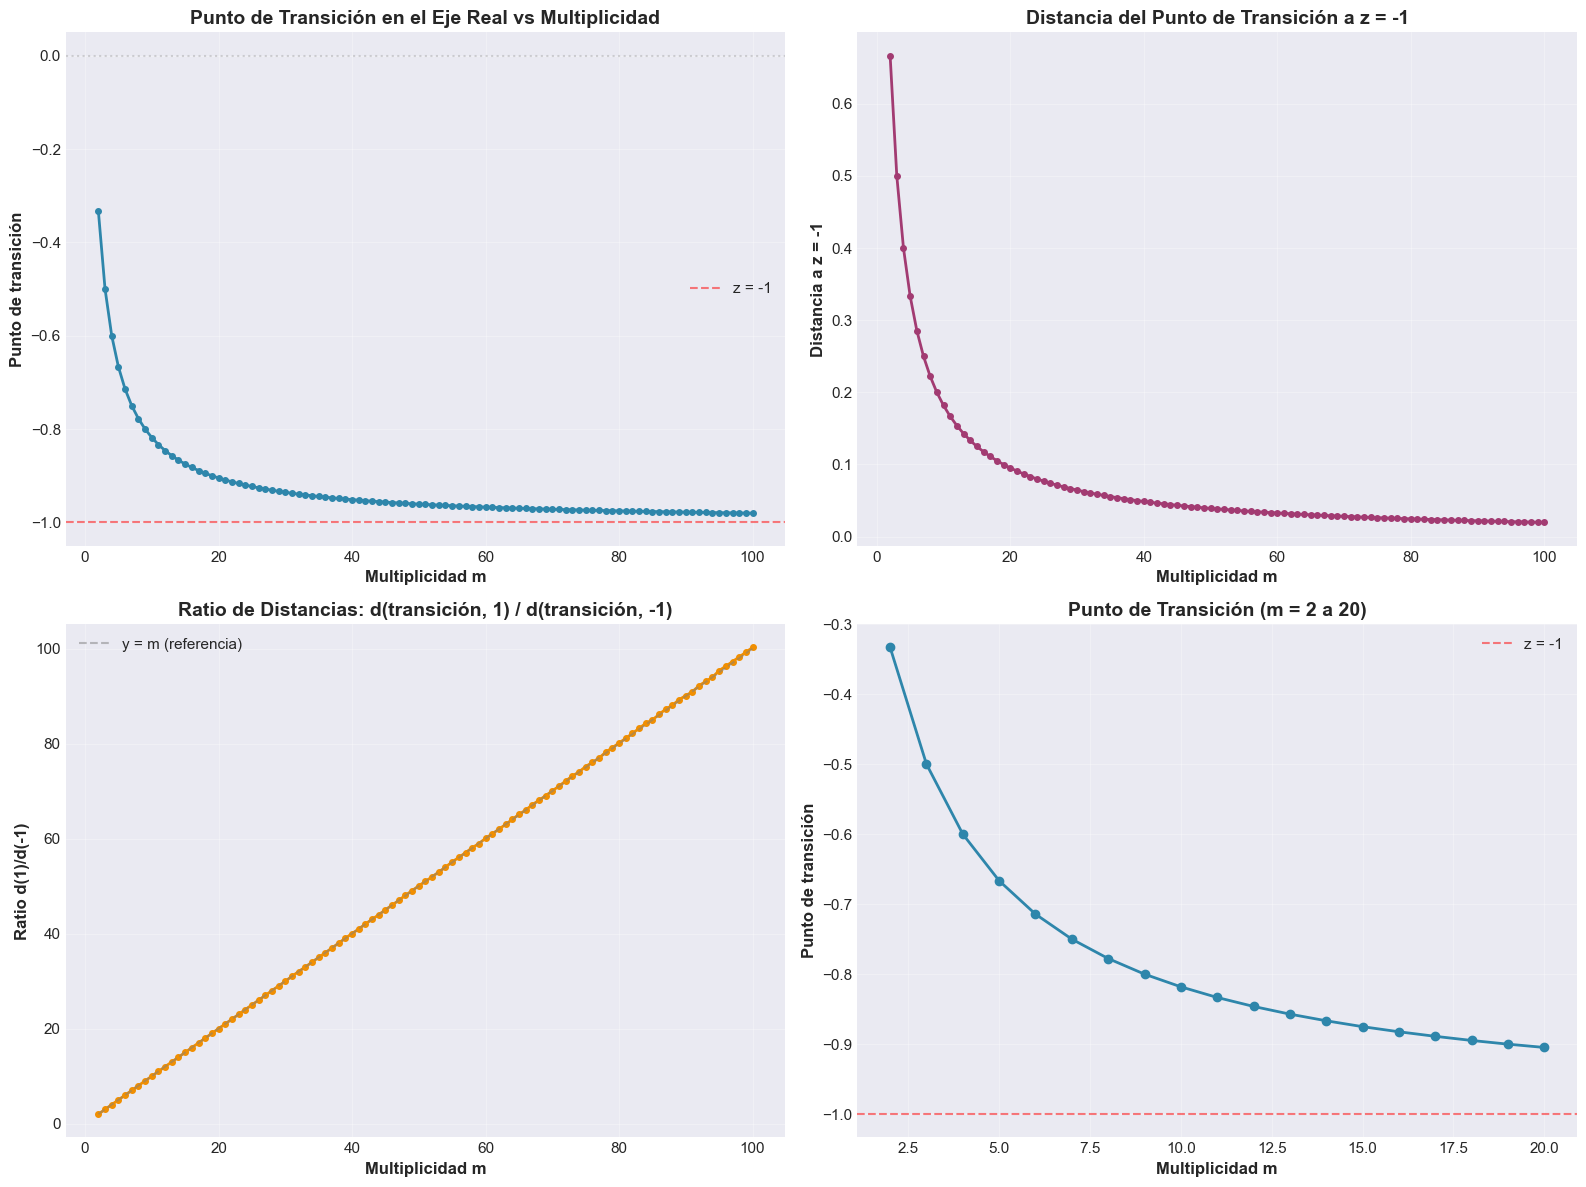

Gráfico guardado: img/analisis_transition_point.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Punto de transición vs m
ax1 = axes[0, 0]
ax1.plot(df['m'], df['transition_point'], 'o-', linewidth=2, markersize=4, color='#2E86AB')
ax1.axhline(-1, color='red', linestyle='--', alpha=0.5, label='z = -1')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.3)
ax1.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax1.set_ylabel('Punto de transición', fontsize=12, fontweight='bold')
ax1.set_title('Punto de Transición en el Eje Real vs Multiplicidad', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Distancia a -1 (desde punto de transición)
ax2 = axes[0, 1]
ax2.plot(df['m'], df['dist_to_minus1'], 'o-', linewidth=2, markersize=4, color='#A23B72')
ax2.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax2.set_ylabel('Distancia a z = -1', fontsize=12, fontweight='bold')
ax2.set_title('Distancia del Punto de Transición a z = -1', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Ratio de distancias
ax3 = axes[1, 0]
ax3.plot(df['m'], df['ratio_dist'], 'o-', linewidth=2, markersize=4, color='#F18F01')
ax3.plot(df['m'], df['m'], '--', color='gray', alpha=0.5, label='y = m (referencia)')
ax3.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax3.set_ylabel('Ratio d(1)/d(-1)', fontsize=12, fontweight='bold')
ax3.set_title('Ratio de Distancias: d(transición, 1) / d(transición, -1)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Gráfico 4: Zoom en primeros valores
ax4 = axes[1, 1]
mask_zoom = df['m'] <= 20
ax4.plot(df[mask_zoom]['m'], df[mask_zoom]['transition_point'], 'o-', 
         linewidth=2, markersize=6, color='#2E86AB')
ax4.axhline(-1, color='red', linestyle='--', alpha=0.5, label='z = -1')
ax4.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax4.set_ylabel('Punto de transición', fontsize=12, fontweight='bold')
ax4.set_title('Punto de Transición (m = 2 a 20)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('img/analisis_transition_point.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/analisis_transition_point.png")

### Ajuste del Punto de Transición

Intentamos ajustar una función del tipo $x_{\text{trans}} = -1 + \frac{a}{m^b}$ para modelar el comportamiento del punto de transición.

Parámetros ajustados:
  a = 1.272767
  b = 0.865548

Fórmula ajustada: x_trans(m) = -1 + 1.272767 / m^0.865548

Error cuadrático medio (RMSE): 0.00603129


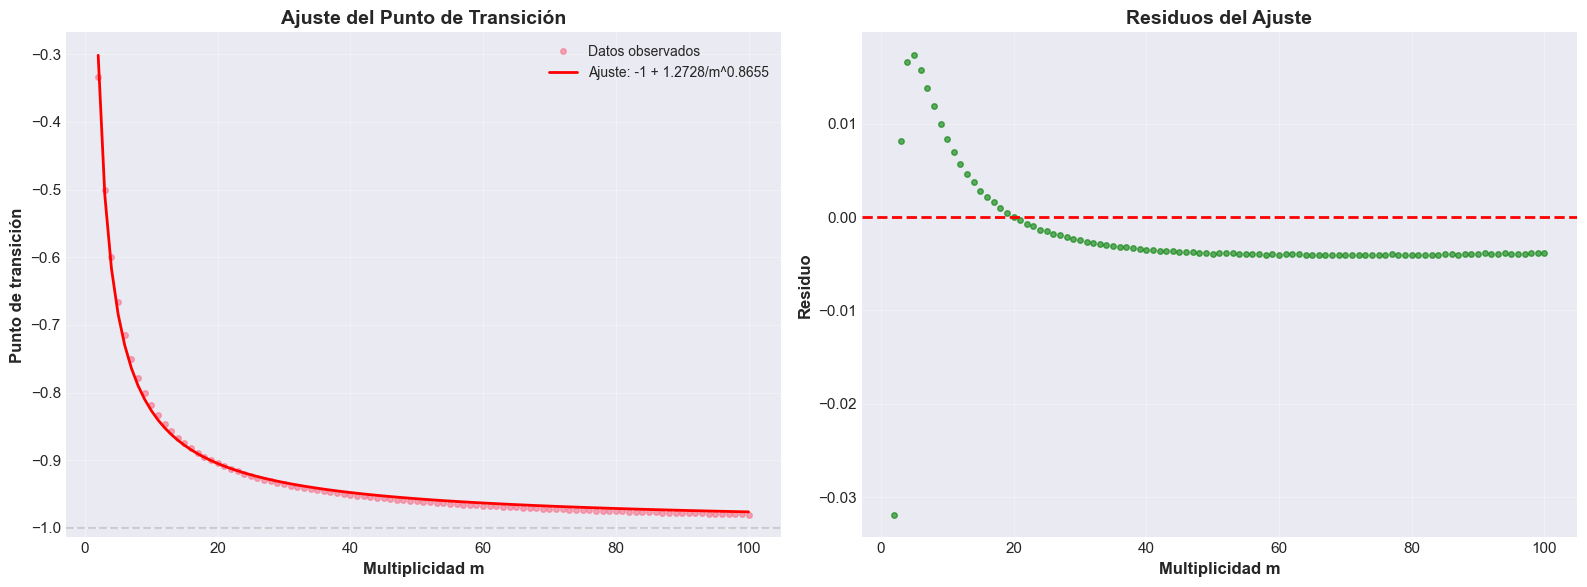


Gráfico guardado: img/ajuste_transition_point.png


In [4]:
# Función de ajuste: x_trans = -1 + a/m^b
def transition_model(m, a, b):
    return -1.0 + a / (m ** b)

# Ajustar la curva
popt, pcov = curve_fit(transition_model, df['m'], df['transition_point'], 
                       p0=[1.0, 1.0], maxfev=10000)

a_fit, b_fit = popt
print(f"Parámetros ajustados:")
print(f"  a = {a_fit:.6f}")
print(f"  b = {b_fit:.6f}")
print(f"\nFórmula ajustada: x_trans(m) = -1 + {a_fit:.6f} / m^{b_fit:.6f}")

# Calcular valores predichos
m_values = df['m'].values
trans_predicted = transition_model(m_values, a_fit, b_fit)

# Calcular error
rmse = np.sqrt(np.mean((df['transition_point'].values - trans_predicted)**2))
print(f"\nError cuadrático medio (RMSE): {rmse:.8f}")

# Visualizar el ajuste
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(df['m'], df['transition_point'], 'o', markersize=4, alpha=0.6, label='Datos observados')
ax1.plot(df['m'], trans_predicted, '-', linewidth=2, color='red', 
         label=f'Ajuste: -1 + {a_fit:.4f}/m^{b_fit:.4f}')
ax1.axhline(-1, color='gray', linestyle='--', alpha=0.3)
ax1.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax1.set_ylabel('Punto de transición', fontsize=12, fontweight='bold')
ax1.set_title('Ajuste del Punto de Transición', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Residuos
ax2 = axes[1]
residuals = df['transition_point'].values - trans_predicted
ax2.plot(df['m'], residuals, 'o', markersize=4, alpha=0.6, color='green')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuo', fontsize=12, fontweight='bold')
ax2.set_title('Residuos del Ajuste', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/ajuste_transition_point.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado: img/ajuste_transition_point.png")

## 3. Análisis del Porcentaje de Convergencia a z = -1

Estudiamos cómo disminuye el porcentaje de puntos que convergen a $z=-1$ a medida que aumenta $m$.

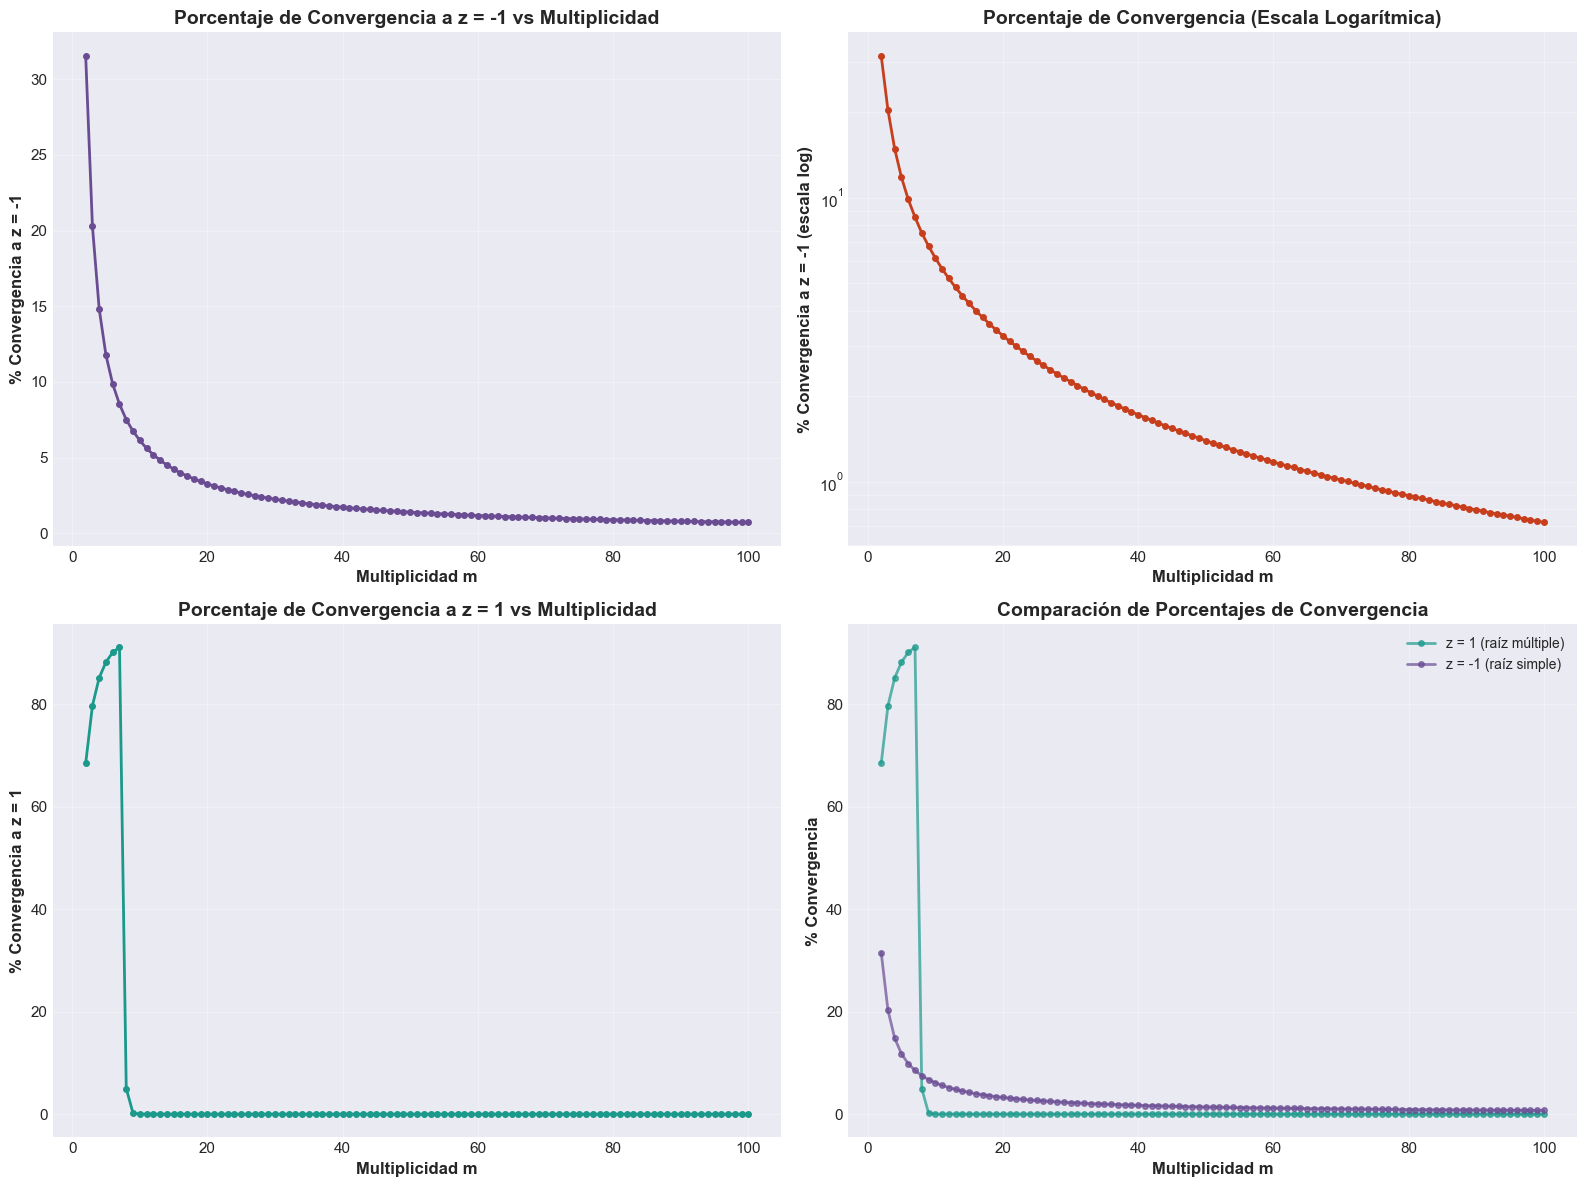

Gráfico guardado: img/analisis_porcentajes.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Porcentaje a -1 vs m
ax1 = axes[0, 0]
ax1.plot(df['m'], df['pct_to_minus1'], 'o-', linewidth=2, markersize=4, color='#6A4C93')
ax1.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax1.set_ylabel('% Convergencia a z = -1', fontsize=12, fontweight='bold')
ax1.set_title('Porcentaje de Convergencia a z = -1 vs Multiplicidad', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Escala logarítmica en y
ax2 = axes[0, 1]
ax2.semilogy(df['m'], df['pct_to_minus1'], 'o-', linewidth=2, markersize=4, color='#C73E1D')
ax2.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Convergencia a z = -1 (escala log)', fontsize=12, fontweight='bold')
ax2.set_title('Porcentaje de Convergencia (Escala Logarítmica)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')

# Gráfico 3: Porcentaje a 1 vs m
ax3 = axes[1, 0]
ax3.plot(df['m'], df['pct_to_1'], 'o-', linewidth=2, markersize=4, color='#1B998B')
ax3.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax3.set_ylabel('% Convergencia a z = 1', fontsize=12, fontweight='bold')
ax3.set_title('Porcentaje de Convergencia a z = 1 vs Multiplicidad', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Ambos porcentajes juntos
ax4 = axes[1, 1]
ax4.plot(df['m'], df['pct_to_1'], 'o-', linewidth=2, markersize=4, 
         color='#1B998B', label='z = 1 (raíz múltiple)', alpha=0.7)
ax4.plot(df['m'], df['pct_to_minus1'], 'o-', linewidth=2, markersize=4, 
         color='#6A4C93', label='z = -1 (raíz simple)', alpha=0.7)
ax4.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax4.set_ylabel('% Convergencia', fontsize=12, fontweight='bold')
ax4.set_title('Comparación de Porcentajes de Convergencia', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/analisis_porcentajes.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado: img/analisis_porcentajes.png")

### Ajuste Exponencial del Porcentaje a z = -1

Ajustamos una función exponencial del tipo $\text{pct}(m) = a \cdot e^{-b \cdot m} + c$ para modelar la disminución.

Parámetros ajustados:
  a = 42.976491
  b = 0.246941
  c = 1.513288

Fórmula ajustada: pct(m) = 42.976491 * exp(-0.246941 * m) + 1.513288

Error cuadrático medio (RMSE): 0.935730%


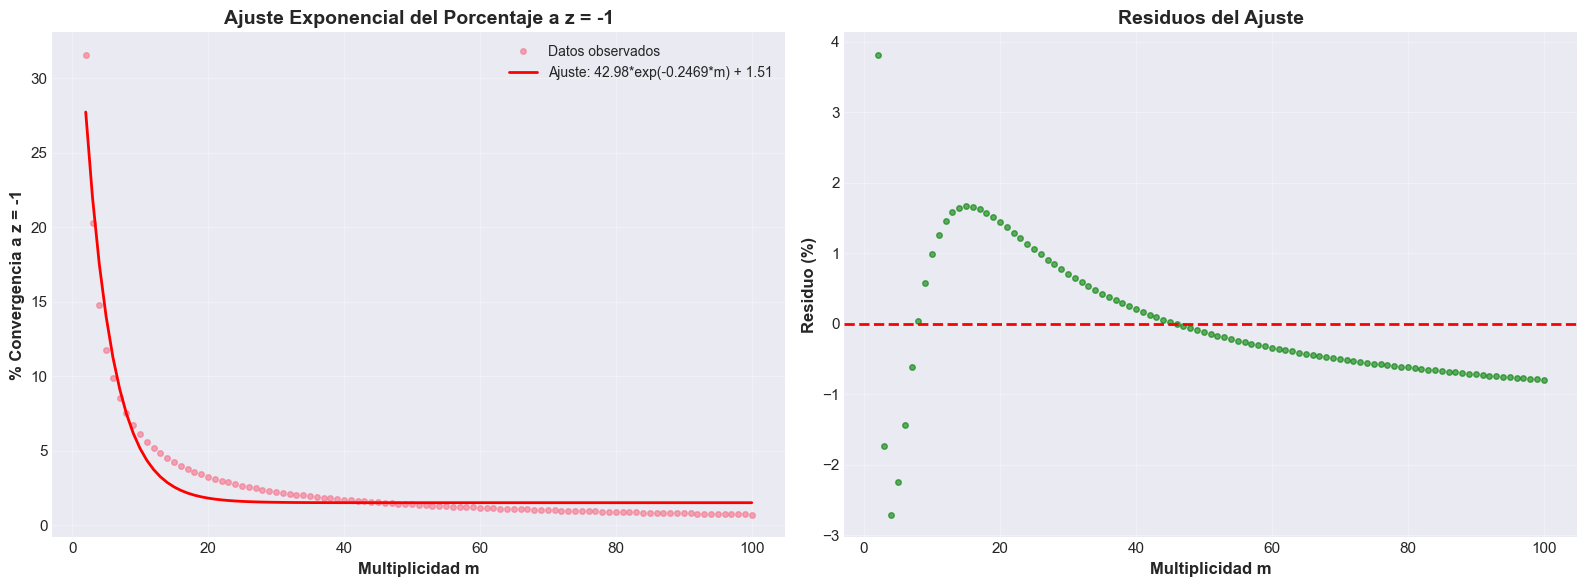


Gráfico guardado: img/ajuste_porcentajes.png


In [6]:
# Función de ajuste exponencial
def exp_decay(m, a, b, c):
    return a * np.exp(-b * m) + c

# Ajustar la curva
popt_pct, pcov_pct = curve_fit(exp_decay, df['m'], df['pct_to_minus1'], 
                                p0=[50.0, 0.1, 0.5], maxfev=10000)

a_pct, b_pct, c_pct = popt_pct
print(f"Parámetros ajustados:")
print(f"  a = {a_pct:.6f}")
print(f"  b = {b_pct:.6f}")
print(f"  c = {c_pct:.6f}")
print(f"\nFórmula ajustada: pct(m) = {a_pct:.6f} * exp(-{b_pct:.6f} * m) + {c_pct:.6f}")

# Calcular valores predichos
pct_predicted = exp_decay(m_values, a_pct, b_pct, c_pct)

# Calcular error
rmse_pct = np.sqrt(np.mean((df['pct_to_minus1'].values - pct_predicted)**2))
print(f"\nError cuadrático medio (RMSE): {rmse_pct:.6f}%")

# Visualizar el ajuste
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(df['m'], df['pct_to_minus1'], 'o', markersize=4, alpha=0.6, label='Datos observados')
ax1.plot(df['m'], pct_predicted, '-', linewidth=2, color='red', 
         label=f'Ajuste: {a_pct:.2f}*exp(-{b_pct:.4f}*m) + {c_pct:.2f}')
ax1.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax1.set_ylabel('% Convergencia a z = -1', fontsize=12, fontweight='bold')
ax1.set_title('Ajuste Exponencial del Porcentaje a z = -1', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Residuos
ax2 = axes[1]
residuals_pct = df['pct_to_minus1'].values - pct_predicted
ax2.plot(df['m'], residuals_pct, 'o', markersize=4, alpha=0.6, color='green')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Multiplicidad m', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuo (%)', fontsize=12, fontweight='bold')
ax2.set_title('Residuos del Ajuste', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/ajuste_porcentajes.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGráfico guardado: img/ajuste_porcentajes.png")

## 4. Relación entre Punto de Transición y Porcentaje

Exploramos si existe una relación directa entre el punto de transición y el porcentaje de convergencia.

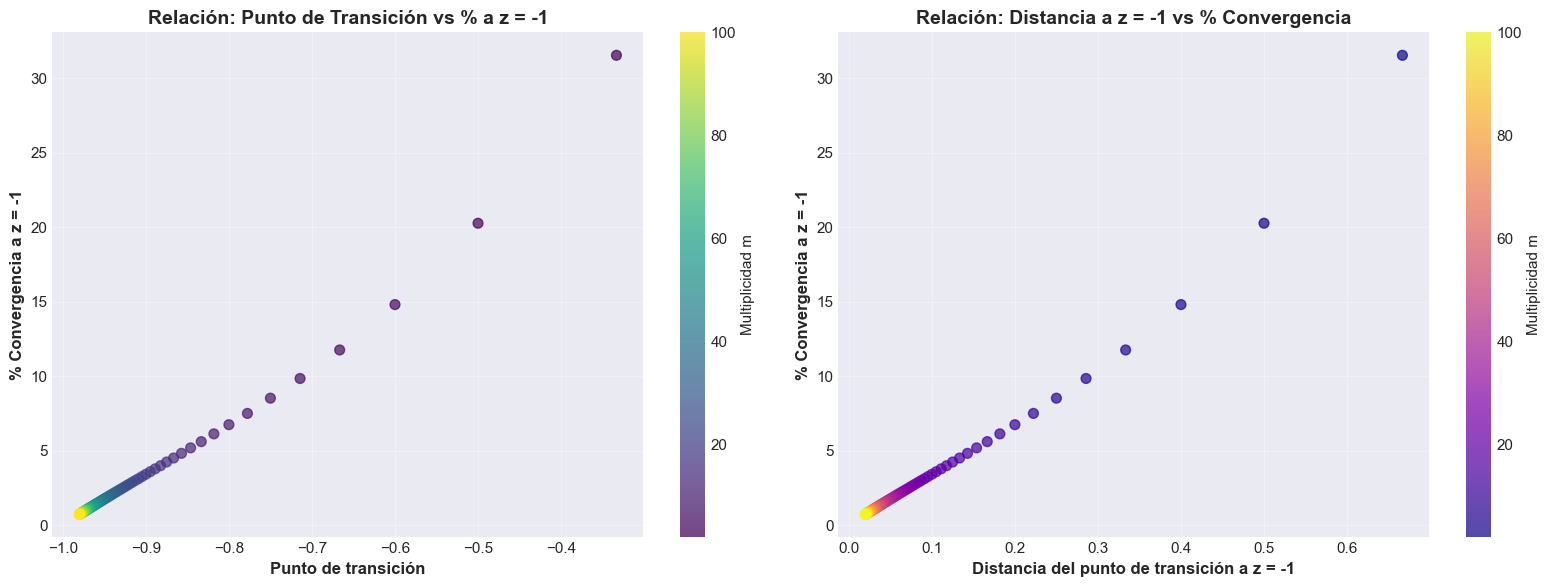

Correlación (punto de transición, % a -1): 0.988623
Correlación (distancia a -1, % a -1): 0.988623

Gráfico guardado: img/relacion_transition_porcentaje.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter plot
ax1 = axes[0]
scatter = ax1.scatter(df['transition_point'], df['pct_to_minus1'], 
                     c=df['m'], cmap='viridis', s=50, alpha=0.7)
ax1.set_xlabel('Punto de transición', fontsize=12, fontweight='bold')
ax1.set_ylabel('% Convergencia a z = -1', fontsize=12, fontweight='bold')
ax1.set_title('Relación: Punto de Transición vs % a z = -1', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Multiplicidad m', fontsize=11)

# Gráfico 2: Correlación con distancia a -1
ax2 = axes[1]
scatter2 = ax2.scatter(df['dist_to_minus1'], df['pct_to_minus1'], 
                      c=df['m'], cmap='plasma', s=50, alpha=0.7)
ax2.set_xlabel('Distancia del punto de transición a z = -1', fontsize=12, fontweight='bold')
ax2.set_ylabel('% Convergencia a z = -1', fontsize=12, fontweight='bold')
ax2.set_title('Relación: Distancia a z = -1 vs % Convergencia', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Multiplicidad m', fontsize=11)

plt.tight_layout()
plt.savefig('img/relacion_transition_porcentaje.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcular correlaciones
corr_trans_pct = df[['transition_point', 'pct_to_minus1']].corr().iloc[0, 1]
corr_dist_pct = df[['dist_to_minus1', 'pct_to_minus1']].corr().iloc[0, 1]

print(f"Correlación (punto de transición, % a -1): {corr_trans_pct:.6f}")
print(f"Correlación (distancia a -1, % a -1): {corr_dist_pct:.6f}")
print("\nGráfico guardado: img/relacion_transition_porcentaje.png")

## 5. Tabla Resumen de Valores Clave

In [8]:
# Crear tabla resumen para valores específicos de m
key_values = [2, 3, 4, 5, 10, 20, 50, 100]
summary_df = df[df['m'].isin(key_values)][['m', 'pct_to_1', 'pct_to_minus1', 
                                            'transition_point', 'dist_to_minus1', 'ratio_dist']]

print("\n" + "="*100)
print("TABLA RESUMEN: Valores clave para multiplicidades seleccionadas")
print("="*100)
display(summary_df.style.format({
    'pct_to_1': '{:.3f}%',
    'pct_to_minus1': '{:.3f}%',
    'transition_point': '{:.8f}',
    'dist_to_minus1': '{:.8f}',
    'ratio_dist': '{:.6f}'
}))

# Estadísticas adicionales
print("\n" + "="*100)
print("ESTADÍSTICAS GLOBALES")
print("="*100)
print(f"Punto de transición inicial (m=2): {df.iloc[0]['transition_point']:.8f}")
print(f"Punto de transición final (m=100): {df.iloc[-1]['transition_point']:.8f}")
print(f"Cambio total en punto de transición: {df.iloc[-1]['transition_point'] - df.iloc[0]['transition_point']:.8f}")
print(f"\n% convergencia a z=-1 inicial (m=2): {df.iloc[0]['pct_to_minus1']:.3f}%")
print(f"% convergencia a z=-1 final (m=100): {df.iloc[-1]['pct_to_minus1']:.3f}%")
print(f"Reducción en % de convergencia: {df.iloc[0]['pct_to_minus1'] - df.iloc[-1]['pct_to_minus1']:.3f}%")
print(f"\nRatio d(1)/d(-1) inicial (m=2): {df.iloc[0]['ratio_dist']:.6f}")
print(f"Ratio d(1)/d(-1) final (m=100): {df.iloc[-1]['ratio_dist']:.6f}")


TABLA RESUMEN: Valores clave para multiplicidades seleccionadas


,m,pct_to_1,pct_to_minus1,transition_point,dist_to_minus1,ratio_dist
0,2,68.452%,31.548%,-0.33331667,0.66668333,1.999925
1,3,79.726%,20.274%,-0.50002500,0.49997500,3.000200
2,4,85.187%,14.813%,-0.60003000,0.39997000,4.000375
3,5,88.232%,11.767%,-0.66663333,0.33336667,4.999400
8,10,0.018%,6.135%,-0.81814091,0.18185909,9.997525
18,20,0.000%,3.267%,-0.90474524,0.09525476,19.996325
48,50,0.000%,1.396%,-0.96084804,0.03915196,50.083014
98,100,0.000%,0.720%,-0.98024901,0.01975099,100.260759



ESTADÍSTICAS GLOBALES
Punto de transición inicial (m=2): -0.33331667
Punto de transición final (m=100): -0.98024901
Cambio total en punto de transición: -0.64693235

% convergencia a z=-1 inicial (m=2): 31.548%
% convergencia a z=-1 final (m=100): 0.720%
Reducción en % de convergencia: 30.828%

Ratio d(1)/d(-1) inicial (m=2): 1.999925
Ratio d(1)/d(-1) final (m=100): 100.260759


## 6. Conclusiones

### Comportamiento del Punto de Transición
- El punto de transición se desplaza desde aproximadamente $-0.333$ (cuando $m=2$) hacia $-1$ a medida que $m$ aumenta
- El ajuste $x_{\text{trans}}(m) = -1 + a/m^b$ captura bien este comportamiento asintótico
- Para valores grandes de $m$, el punto de transición se aproxima a $-1$ (la raíz simple)

### Comportamiento del Porcentaje de Convergencia
- El porcentaje de convergencia a $z=-1$ disminuye exponencialmente con $m$
- Cuando $m=2$, aproximadamente el 31.5% de los puntos convergen a $z=-1$
- Cuando $m=100$, solo el 0.72% de los puntos convergen a $z=-1$
- La raíz múltiple $z=1$ domina cada vez más la cuenca de atracción

### Relación entre Variables
- Existe una fuerte correlación entre el punto de transición y el porcentaje de convergencia
- A medida que el punto de transición se acerca a $-1$, la cuenca de $z=-1$ se reduce
- El ratio $d(1)/d(-1)$ crece aproximadamente linealmente con $m$